# 计算态演化

## 演化案例

In [5]:
import quante as qt
import numpy as np
op = qt.generate.operas

L = 10
tlist = np.linspace(0, 10, 200)

# Model
J, γ = 1., 0.1
builder = op.SpinBuilder()
for l in range(L-1):
    builder += "+-", [l+1, l], (J+γ)/2
    builder += "+-", [l, l+1], (J-γ)/2
ham = builder.build()

basis = qt.generate.basis.spin_basis(L=L)
obsoper = [op.z(i) for i in range(L)]
init_state = qt.generate.state.neel(L=L, down_first=True)

res = ham.evolve_and_measure(init_state, tlist, obsoper, basis=basis, method='cpu_mul', normalize=True)
res1 = ham.evolve_and_measure(init_state, tlist, obsoper, basis=basis, method='eig', normalize=True)
res - res1

100%|##########| 200/200 [00:00<00:00, 609.58it/s]


array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0., -0., -0., ...,  0.,  0., -0.],
       [-0.,  0., -0., ...,  0., -0.,  0.],
       ...,
       [-0.,  0.,  0., ..., -0., -0.,  0.],
       [-0.,  0.,  0., ..., -0., -0.,  0.],
       [-0.,  0.,  0., ..., -0., -0.,  0.]])

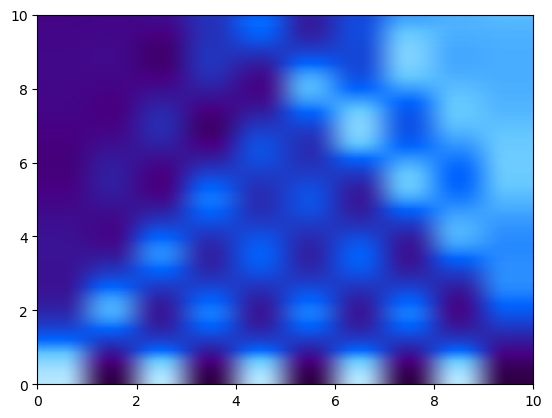

In [6]:
# 可视化

import matplotlib.pyplot as plt
# from tqdm import tqdm
from IPython.display import clear_output, display
op = qt.generate.operas
from matplotlib.colors import LinearSegmentedColormap
colors = [
    (48/255, 0/255, 70/255),   # 深紫色
    (72/255, 0/255, 130/255),  # 紫
    (50/255, 30/255, 160/255), # 紫蓝
    (30/255, 60/255, 200/255), # 深蓝
    (0/255, 100/255, 255/255), # 蓝色
    (100/255, 200/255, 255/255), # 淡蓝
    (180/255, 230/255, 255/255)  # 青色 / 浅青蓝
]
# 创建平滑渐变的 colormap，插值成 256 个颜色
custom_cmap = LinearSegmentedColormap.from_list("smooth_purple_blue", colors, N=256)
plt.imshow(res, aspect='auto', extent=(0, L, 0, 10), cmap=custom_cmap, origin='lower')  # 设置 

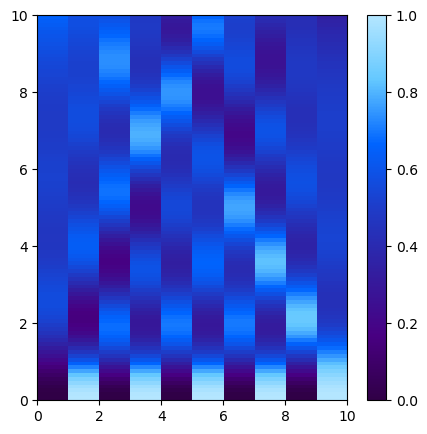

In [7]:
def amh_method(L=10, tmax=10, delta_t=0.1, gamma=0., device=None):
    tnum = int(tmax/delta_t)
    tlist = np.linspace(0, tmax, tnum)
    
    # Model
    J, γ = 1., gamma
    builder = op.SpinBuilder()
    for l in range(L-1):
        builder += "+-", [l+1, l], (J+γ)/2
        builder += "+-", [l, l+1], (J-γ)/2
    ham = builder.build()

    basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)
    hammat = ham.to_matrix(basis=basis, sparse=True)
    
    # Observation
    obsoper = [op.z(i) for i in range(L)]

    # Initial state
    arr = basis.s_list
    n = int(eval(''.join(['0b'] + ['10'] * (L//2))))
    indices = np.where(arr == n)[0]
    init_state = np.zeros(basis.Ns, dtype=complex)
    init_state[indices] = 1.0

    # Plot
    res = np.full((L, len(tlist)), np.nan, dtype=float)
    plt.figure(figsize=(5, 5))
    img = plt.imshow(res, aspect='auto', extent=(0, L, 0, tmax), cmap=custom_cmap, origin='lower')  # 设置 
    img.set_clim(0, 1)
    plt.colorbar(img)
    # pbar = tqdm(total=len(tlist), dynamic_ncols=True, ascii=True)

    # Evolve
    if device is None:
        evolve_engine = qt.linalg.EvolveEngine(hammat, init_state, ts=tlist)
        obsmatlist = [ob.to_matrix(basis, sparse=True).diagonal().reshape(-1,1) for ob in obsoper]
        for i in range(len(tlist)):
            evolve_engine.run()
            evolve_engine.psi /= np.linalg.norm(evolve_engine.psi)
            state = evolve_engine.psi
            for j in range(len(obsmatlist)):
                value = state.conj().reshape(1,-1) @ (obsmatlist[j] * state)
                res[j, i] = np.real(value[0].item() + 0.5)
            img.set_data(res.T)  # 更新图像数据
            clear_output(wait=True)  # 清除输出
            display(plt.gcf())  # 显示当前图形
            # plt.pause(0.1) # 如果是py文件中需要将上面的clear_output和display替换为plt.pause(0.1)
            # pbar.set_postfix({"t": f"{tlist[i]:.2f}"})
            # pbar.update(1)
    else:
        import quante.torch_utils as qtc
        import torch as tc
        tcmat = qtc.linalg.to_csr(hammat, device=device)
        obsmatlist = [tc.tensor(ob.to_matrix(basis, sparse=True).diagonal().reshape(-1,1), device=device, dtype=tc.complex128) for ob in obsoper]
        init_state = tc.tensor(init_state, device=device)
        evolve_engine = qtc.linalg.EvolveEngine(tcmat, init_state, ts=tlist)
        for i in range(len(tlist)):
            evolve_engine.run()
            evolve_engine.psi /= tc.linalg.norm(evolve_engine.psi)
            state = evolve_engine.psi.to(device)
            for j in range(len(obsmatlist)):
                value = state.conj().reshape(1,-1) @ (obsmatlist[j] * state)
                res[j, i] = np.real(value[0,0].item() + 0.5)
            img.set_data(res.T)  # 更新图像数据
            clear_output(wait=True)  # 清除输出
            display(plt.gcf())  # 显示当前图形
            # plt.pause(0.1) # 如果是py文件中需要将上面的clear_output和display替换为plt.pause(0.1)
            # pbar.set_postfix({"t": f"{tlist[i]:.2f}"})
            # pbar.update(1)
    clear_output(wait=True)  # 清除输出
    # plt.show()

amh_method()

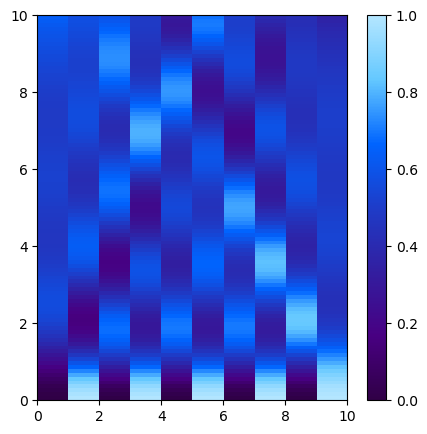

In [8]:
def tn_method(L=10, tmax=10, delta_t=0.1, gamma=0.):
    J, γ = 1., gamma
    builder = op.SpinBuilder()
    for l in range(L-1):
        builder += "+-", [l+1, l], (J+γ)/2
        builder += "+-", [l, l+1], (J-γ)/2
    ham = builder.build()

    import torch as tc
    import quante.torch_utils as qtc

    𝜓t = qtc.MPS.from_product_state(["down", "up"]*(L//2), dtype=tc.complex128)
    gates = ham.trotter_gates(L, tau=delta_t, order='2', pauli=False)
    num = int(tmax//delta_t)

    # Plot
    res = np.full((num, L), np.nan, dtype=float)
    plt.figure(figsize=(5, 5))
    img = plt.imshow(res, aspect='auto', extent=(0, L, 0, tmax), cmap=custom_cmap, origin='lower')  # 设置 
    img.set_clim(0, 1)
    plt.colorbar(img)

    # pbar = tqdm(total=num, dynamic_ncols=True, ascii=True)
    for i in range(num):
        for pos, gate in zip(*gates):
            𝜓t.apply_gate_(pos, gate, trunc_para=(None, None, 1e-20))
        𝜓t.normalize_()
        res[i, :] = np.real_if_close([𝜓t.measure('z', i).item().real for i in range(L)]) + 0.5
        img.set_data(res)  # 更新图像数据
        clear_output(wait=True)  # 清除输出
        display(plt.gcf())  # 显示当前图形
        # plt.pause(0.1) # 如果是py文件中需要将上面的clear_output和display替换为plt.pause(0.1)
        
        # pbar.set_postfix({"bond dim": f"{𝜓t.maxbonddim()}"})
        # pbar.update(1)
    
    clear_output(wait=True)  # 清除输出
    # plt.show()

tn_method()

100%|##########| 200/200 [00:00<00:00, 452.96it/s]


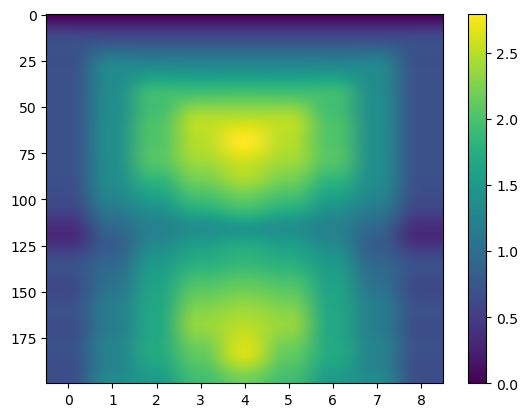

In [13]:
import quante as qt
import numpy as np
op = qt.generate.operas

L = 10
tlist = np.linspace(0, 20, 200)

# Model
J, γ = 1., 0.
builder = op.SpinBuilder()
for l in range(L-1):
    builder += "+-", [l+1, l], (J+γ)/2
    builder += "+-", [l, l+1], (J-γ)/2
ham = builder.build()

basis = qt.generate.basis.spin_basis(L=L, Nup=L//2)

obs = lambda t, state: [qt.quantity.entanglement_entropy(state, L, i, basis=basis) for i in range(1,L)]

init_state = qt.generate.state.neel(L=L, down_first=True, Nup=L//2)
res = ham.evolve_and_measure(init_state, tlist, obs, basis=basis, method='cpu_mul')
plt.imshow(res, aspect='auto')
plt.colorbar()

## 主方程演化

PHYSICAL REVIEW LETTERS 127, 070402 (2021)

$$
    \mathcal{L}(\rho) = -i [H, \rho] + \sum_{l} L_l \rho L_l^{\dagger} - \frac{1}{2} \sum_{l} (L_l^{\dagger} L_l \rho + \rho L_l^{\dagger} L_l)
$$

In [17]:
import quante as qt
import numpy as np

op = qt.generate.operas.boson.BosonOper

L = 30
J = 1.
gamma_R = 1.0
gamma_L = 0.5

ham = op.builder()
for i in range(L-1):
    ham += "+-", [i+1, i], -J
    ham += "+-", [i, i+1], -J
ham = ham.build()

basis = qt.generate.basis.quspin_boson_basis(L=L, Nb=1)
hammat = ham.to_matrix(basis=basis, sparse=True)

Lindblad_R = [np.sqrt(gamma_R) * op.pm(i+1,i).to_matrix(basis=basis, sparse=True) for i in range(L-1)]
Lindblad_L = [np.sqrt(gamma_L) * op.pm(i,i+1).to_matrix(basis=basis, sparse=True) for i in range(L-1)]
particle_number = [op.n(i).to_matrix(basis=basis, sparse=True) for i in range(L)]

lvn = qt.linalg.Liouvillian(hammat, Lindblad_R + Lindblad_L)
state = qt.generate.state.product_state('1'+'0'*(L-1), Nup=1)
rhoinit = np.outer(state, state)

res = lvn.evolve_and_measure(
    rhoinit, [10, 20, 30, 40, 50], 
    measure=particle_number, 
    method='eig'
)

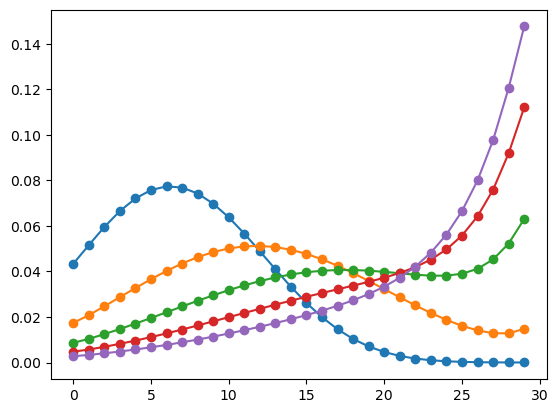

In [18]:
import matplotlib.pyplot as plt
plt.plot(res.T, 'o-')

## 不同方法的 benchmark

In [19]:
import quante as qt
L = 12
ham = qt.generate.operas.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
state = qt.generate.state.random(basis.Ns, seed=42)
qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, herm=True)

array([[[ 0.00335624+0.00606165j],
        [-0.01145467+0.0090065j ],
        [ 0.00826567+0.0048053j ],
        ...,
        [-0.01305153+0.00220341j],
        [ 0.00607938+0.00661749j],
        [-0.01943596+0.01879979j]],

       [[ 0.0048898 +0.00490894j],
        [-0.00893959+0.01087129j],
        [ 0.01002091+0.00476051j],
        ...,
        [-0.01273198+0.00414389j],
        [ 0.00764766+0.00570824j],
        [-0.01353566+0.02340886j]],

       [[ 0.00604849+0.00337989j],
        [-0.00609528+0.01202976j],
        [ 0.01195179+0.00416268j],
        ...,
        [-0.01204725+0.00597486j],
        [ 0.00906296+0.00443277j],
        [-0.00659764+0.02622327j]],

       ...,

       [[ 0.00508586-0.00470552j],
        [ 0.0022496 +0.01370704j],
        [-0.00079423+0.0112147j ],
        ...,
        [ 0.00022375+0.00682789j],
        [ 0.00216894-0.0012144j ],
        [ 0.02289399+0.01438937j]],

       [[ 0.00360056-0.00591979j],
        [ 0.0058218 +0.01275967j],
        [ 0.00174

In [1]:
import quante as qt
import numpy as np
import scipy.sparse as sp
import time

## 初始化态和哈密顿量

In [2]:
# 拿到矩阵
L = 12
ham = qt.generate.operas.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

## 比较不同方法的计算结果

### 用本征分解的方法计算

In [5]:
res = qt.linalg.eigh(mat)
times = np.linspace(0,10,100)
qt.linalg.get_time_evolution_states_ED(state,*res,times, device_name='cpu')

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 用 scipy 的 expm_multiply

In [6]:
res = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

### 使用 quante 的 expm_multiply

In [7]:
res = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

针对实矩阵的优化

In [9]:
res = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100)
np.squeeze(res).T

array([[ 0.00335624+0.00606165j,  0.0048898 +0.00490894j,  0.00604849+0.00337989j, ...,  0.00508586-0.00470552j,  0.00360056-0.00591979j,  0.00183922-0.00668021j],
       [-0.01145467+0.0090065j , -0.00893959+0.01087129j, -0.00609528+0.01202976j, ...,  0.0022496 +0.01370704j,  0.0058218 +0.01275967j,  0.00901401+0.01092018j],
       [ 0.00826567+0.0048053j ,  0.01002091+0.00476051j,  0.01195179+0.00416268j, ..., -0.00079423+0.0112147j ,  0.00174312+0.01032498j,  0.00388811+0.00880588j],
       ...,
       [-0.01305153+0.00220341j, -0.01273198+0.00414389j, -0.01204725+0.00597486j, ...,  0.00022375+0.00682789j,  0.00212203+0.00639483j,  0.00377646+0.00548359j],
       [ 0.00607938+0.00661749j,  0.00764766+0.00570824j,  0.00906296+0.00443277j, ...,  0.00216894-0.0012144j ,  0.0021677 -0.00177j   ,  0.00199682-0.00239705j],
       [-0.01943596+0.01879979j, -0.01353566+0.02340886j, -0.00659764+0.02622327j, ...,  0.02289399+0.01438937j,  0.02596224+0.00755981j,  0.02704008+0.00015067j]])

## 比较运行速度

生成一个较大的矩阵

In [10]:
# 拿到矩阵
L = 18
ham = qt.generate.operas.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

space dimension: 262144


比较四种方法运行所需要的时间

In [13]:
# 方法1:
import scipy.sparse as sp

t = time.time()
res1 = sp.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100)
print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

t = time.time()
res2 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, herm=True)
print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

t = time.time()
res3 = qt.linalg.expm_multiply((-1j*mat), state, start=0, stop=10, num=100, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

t = time.time()
res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', start=0, stop=10, num=100, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

print("norm difference between first two:", np.allclose(res1, res2))
print("norm difference between last two:", np.allclose(res2, res3))
print("norm difference between last two:", np.allclose(res3, res4))

time scipy.expm_multiple: 23.18s
time quante.expm_multiple with cpu parallel: 15.32s
time quante.expm_multiple with gpu cuda: 2.40s
time quante.expm_multiple with gpu cuda: 1.21s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True


建一个更大的矩阵

In [14]:
L = 22
ham = qt.generate.operas.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)
mat = ham.to_matrix(basis, sparse=True)
print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

space dimension: 4194304


演化 1s 需要的时间

In [15]:
# 方法1:
t = time.time()
res1 = sp.linalg.expm_multiply((-1j*mat), state)
print(f"time scipy.expm_multiple: {time.time()-t:.2f}s")

t = time.time()
res2 = qt.linalg.expm_multiply((-1j*mat), state, herm=True)
print(f"time quante.expm_multiple with cpu parallel: {time.time()-t:.2f}s")

t = time.time()
res3 = qt.linalg.expm_multiply((-1j*mat), state, device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

t = time.time()
res4 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

print("norm difference between first two:", np.allclose(res1, res2))
print("norm difference between last two:", np.allclose(res1, res3))
print("norm difference between last two:", np.allclose(res1, res4))

time scipy.expm_multiple: 15.10s
time quante.expm_multiple with cpu parallel: 8.78s
time quante.expm_multiple with gpu cuda: 1.94s
time quante.expm_multiple with gpu cuda: 1.14s
norm difference between first two: True
norm difference between last two: True
norm difference between last two: True


所能运行的最大尺寸

In [17]:
# 拿到矩阵
L = 26
ham = qt.generate.operas.heisenberg_operator(L)
ham = ham.expandxy()
basis = qt.generate.basis.spin_basis(L)
t = time.time()
mat = ham.to_matrix(basis, sparse=True)
print(f"time to generate matrix: {time.time()-t:.2f}s")

print("space dimension:", basis.Ns)

# 拿到态
state = qt.generate.state.random(basis.Ns, seed=42)

t = time.time()
res3 = qt.linalg.expm_multiply(mat, state, ttype='real-time', device='cuda:0', herm=True)
print(f"time quante.expm_multiple with gpu cuda: {time.time()-t:.2f}s")

time to generate matrix: 37.75s
space dimension: 67108864
time quante.expm_multiple with gpu cuda: 21.96s


In [19]:
print(f"哈密顿量内存占用：",end="")
qt.basicfun.print_memory_usage(mat)
print(f"演化态内存占用：",end="");
qt.basicfun.print_memory_usage(res3)

哈密顿量内存占用：10.38 GB
演化态内存占用：1.00 GB


## 逐步演化形式

In [3]:
from quante.torch_utils.linalg import evolve_engine, to_csr # 只在 torch 中实现了
import torch as tc

L = 10
ham = qt.generate.operas.heisenberg_operator(L)
basis = qt.generate.basis.spin_basis(L)

# 生成矩阵和向量，并转为 torch tensor
tcmat = to_csr(ham.to_matrix(basis, sparse=True), device='cuda')
tcstate = tc.tensor(qt.generate.state.random(basis.Ns, seed=42), device='cuda')

# 定义演化引擎
eg = evolve_engine(tcmat, scale=-1j, herm=True)

# 进行演化
for i in range(10):
    nextstate = eg(tcstate)
    assert tc.allclose(nextstate, tc.matrix_exp((-1j)*tcmat.to_dense()) @ tcstate)
    
    # ... 做一些其他事情
    
    tcstate = nextstate

e:\hzhu\onedrive\python_library\quante\torch_utils\linalg\sparse.py:21: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  return tc.sparse_csr_tensor(tsr.indptr, tsr.indices, tsr.data, tsr.shape, dtype=dtype, device=device)
